<hr style="border:none;height:6px;background:#fff;margin:1em 0;">


<div style="text-align: center;">
  <h1>Dividend Taxation and Top-Income Inequality</h1>
  <h3>HEC Liege</h3>
  <h4><em>Lucas Dubois</em></h4>
</div>

<hr style="border:none;height:6px;background:#fff;margin:1em 0;">


<hr style="border:none;height:4px;background:#fff;margin:1em 0;">


In [3]:
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

path = '/Users/lucasdubois/Desktop/MASTERDATA/' 
df = pd.read_csv(path + "MASTER_FINAL.csv")
df = df.sort_values(["Country Name", "Year"])

In [4]:
offwhite = (230/255, 230/255, 220/255)
midnight = (0/255, 22/255, 36/255)
steelblue = (171/255, 193/255, 223/255)
primaryred = (127/255, 20/255, 22/255)
harmonizedblue =(48/255,88/255,140/255)

In [5]:
inequality_variables = [
    "top10_inc",
    "top1_inc",
    "top10_w",
    "top1_w",
    "gini_disp",
    "gini_mkt",
    "gini_disp_se",
    "gini_mkt_se"
]

interaction_variables = [
    "log_rgdpe",
    "log_pop",
    "log_emp",
    "log_cn",
    "rgdpe_sq",
    "log_rgdpe_sq",
    "hc_ctfp",
    "labsh_irr",
    "cn_ctfp",
    "xr_irr",
    "csh_g_hc",
    "csh_c_hc",
    "rgdpe_ctfp",
    "pop_rgdpe",
    "delta_cn"
]

id_variables = ["Country Name", "Year"]

X = [
    col for col in df.columns
    if col not in inequality_variables + interaction_variables + id_variables
]

X_numeric = df[X].select_dtypes(include=["number"]).columns.tolist()

<hr style="border:none;height:4px;background:#fff;margin:1em 0;">


<div style="text-align: align;">
  <h2> <small>5</small>&nbsp;&nbsp;&nbsp;&nbsp; Plots:</h2>
</div>

<hr style="border:none; border-top:2px dashed #fff; margin:1em 0;">

<div style="text-align: align;">
  <h3> <small>5.1</small>&nbsp;&nbsp;&nbsp;&nbsp;Running Models:</h3>
</div>

In [6]:
# Filter rows where inflation >= 500
filtered_df = df[df['inflation'] >= 50]

# Select only country and year, then sort by year
result = filtered_df[['Country Name', 'Year']].sort_values(by='Country Name')

# Print the result
print(result)

     Country Name  Year
156        Brazil  1985
157        Brazil  1986
158        Brazil  1987
159        Brazil  1988
160        Brazil  1989
161        Brazil  1990
162        Brazil  1991
163        Brazil  1992
164        Brazil  1993
165        Brazil  1994
166        Brazil  1995
556         Ghana  1995
897        Israel  1985
1251      Nigeria  1988
1252      Nigeria  1989
1256      Nigeria  1993
1257      Nigeria  1994
1258      Nigeria  1995


In [7]:
# Brazil series
df2 = pd.read_csv(path + "MASTER_FINAL_ADJ.csv")
df2 = df2.sort_values(["Country Name", "Year"])

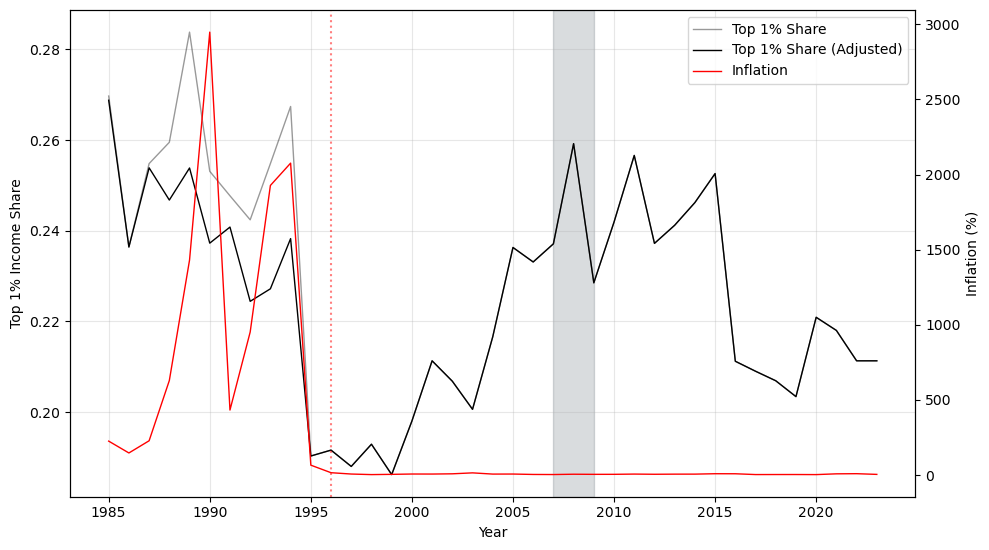

In [15]:
brazil_series_adj=(
    df2[df2["Country Name"] == "Brazil"]
    .sort_values("Year")
    .set_index("Year")["top1_inc"]
)

brazil_series = (
    df[df["Country Name"] == "Brazil"]
    .sort_values("Year")
    .set_index("Year")["top1_inc"]
)

brazil_inflation = (
    df[df["Country Name"] == "Brazil"]
    .sort_values("Year")
    .set_index("Year")["inflation"]
)

# World average inflation by year
world_avg_inflation = (
    df.groupby("Year")["inflation"]
    .mean()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 5.6))

# Left axis → Top 1% income
ax.plot(
    brazil_series.index,
    brazil_series.values,
    label='Top 1% Share',
    color="black",
    alpha=0.4,
    linewidth=1
)

ax.plot(
    brazil_series_adj.index,
    brazil_series_adj.values,
    label='Top 1% Share (Adjusted)',
    color="black",
    linewidth=1
)
ax.set_ylabel('Top 1% Income Share')

# Right axis → Inflation
ax2 = ax.twinx()

ax2.plot(
    brazil_inflation.index,
    brazil_inflation.values,
    label='Inflation',
    color="red",
    linewidth=1
)

ax2.set_ylabel('Inflation (%)')

# Vertical lines & shaded areas
ax.axvline(1996, color="red", linestyle=":", alpha=0.5)
ax.axvspan(2007, 2009, color=midnight, alpha=0.15)

# Title & labels
ax.set_xlabel('Year')
# Combine legends from both axes
lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax.legend(lines_1 + lines_2, labels_1 + labels_2)

ax.grid(True, alpha=0.3)

fig.savefig(
    "/Users/lucasdubois/Desktop/LaTeX/MASTER/TEXT/Images_tex/brazil_inflation_x_topinc.png",
    bbox_inches="tight",
    pad_inches=0.02
)

plt.tight_layout()
plt.show()
plt.close(fig)

In [30]:
%run Master_4_ASCM_Ridge.ipynb

Pre-treatment RMSE (SCM):  0.0236
Pre-treatment RMSE (ASCM): 0.0169

Top SCM donor weights:
Thailand         7.260067e-01
Botswana         2.739933e-01
Iran            -1.676820e-13
India           -2.041210e-13
Philippines     -3.566285e-13
Malaysia        -4.223766e-13
Nigeria         -4.779564e-13
Tanzania        -5.602582e-13
Israel          -6.974843e-13
Sri Lanka       -8.522699e-13
United States   -9.380374e-13
Egypt           -9.440200e-13
Hong Kong       -1.099246e-12
Luxembourg      -1.251909e-12
Japan           -1.431208e-12
dtype: float64

Top ASCM donor weights:
Thailand         0.831779
Botswana         0.246491
Singapore        0.122234
Germany          0.117769
Norway           0.117160
Japan            0.111087
Belgium          0.100011
South Korea      0.098953
Hong Kong        0.089012
India            0.078835
United States    0.057819
Switzerland      0.056812
Sri Lanka        0.049255
New Zealand      0.040743
Iran             0.040555
dtype: float64

Most negativ

In [31]:
covariates = ["emp","ctfp"]

usa_ascm = scm_ascm(
    df=df,
    country="United States",
    treat_year=2003,
    covariates=covariates,
    ridge_lambda=1.0
)

Pre-treatment RMSE (SCM):  0.0076
Pre-treatment RMSE (ASCM): 0.0049

Top SCM donor weights:
Luxembourg        4.315986e-01
India             2.750017e-01
Egypt             2.607661e-01
Brazil            3.263357e-02
Botswana          7.320617e-19
Philippines      -1.793532e-18
Iran             -2.458583e-18
Thailand         -2.737806e-18
Israel           -3.101562e-18
Hong Kong        -4.297982e-18
France           -5.670263e-18
United Kingdom   -6.788269e-18
Malaysia         -6.927869e-18
Sri Lanka        -7.095681e-18
Spain            -7.121038e-18
dtype: float64

Top ASCM donor weights:
Luxembourg     0.436892
India          0.308912
Egypt          0.260146
Australia      0.092538
Germany        0.086674
Japan          0.074769
Belgium        0.069548
Hong Kong      0.049422
Canada         0.047229
New Zealand    0.046019
Spain          0.039969
France         0.038750
Sri Lanka      0.033115
Israel         0.028619
Italy          0.026005
dtype: float64

Most negative ASCM weights:

In [49]:
weights_ascm_usa = usa_ascm["weights_ascm"]


In [52]:
weights_ascm_usa = pd.DataFrame(list(weights_ascm_usa.items()), columns=["country", "value"])

In [55]:
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

In [57]:
mismatches = weights_ascm_usa[~weights_ascm_usa["country"].isin(world["NAME"])]
print(mismatches)

      country     value
7   Hong Kong  0.049422
36  Singapore -0.052161


In [61]:
print(world["NAME"][world["NAME"].str.contains("Hong|Sing", case=False, na=False)])

Series([], Name: NAME, dtype: str)


In [63]:
weights_ascm_usa = weights_ascm_usa[weights_ascm_usa["country"] != "Hong Kong"]

In [64]:
weights_ascm_usa = weights_ascm_usa[weights_ascm_usa["country"] != "Singapore"]

In [66]:
merged = world.merge(weights_ascm_usa, left_on="NAME", right_on="country", how="left")

In [ ]:
def mundi_validation(weights)
    return
        weights = pd.DataFrame(list(weights.items()), columns=["country", "value"])
    

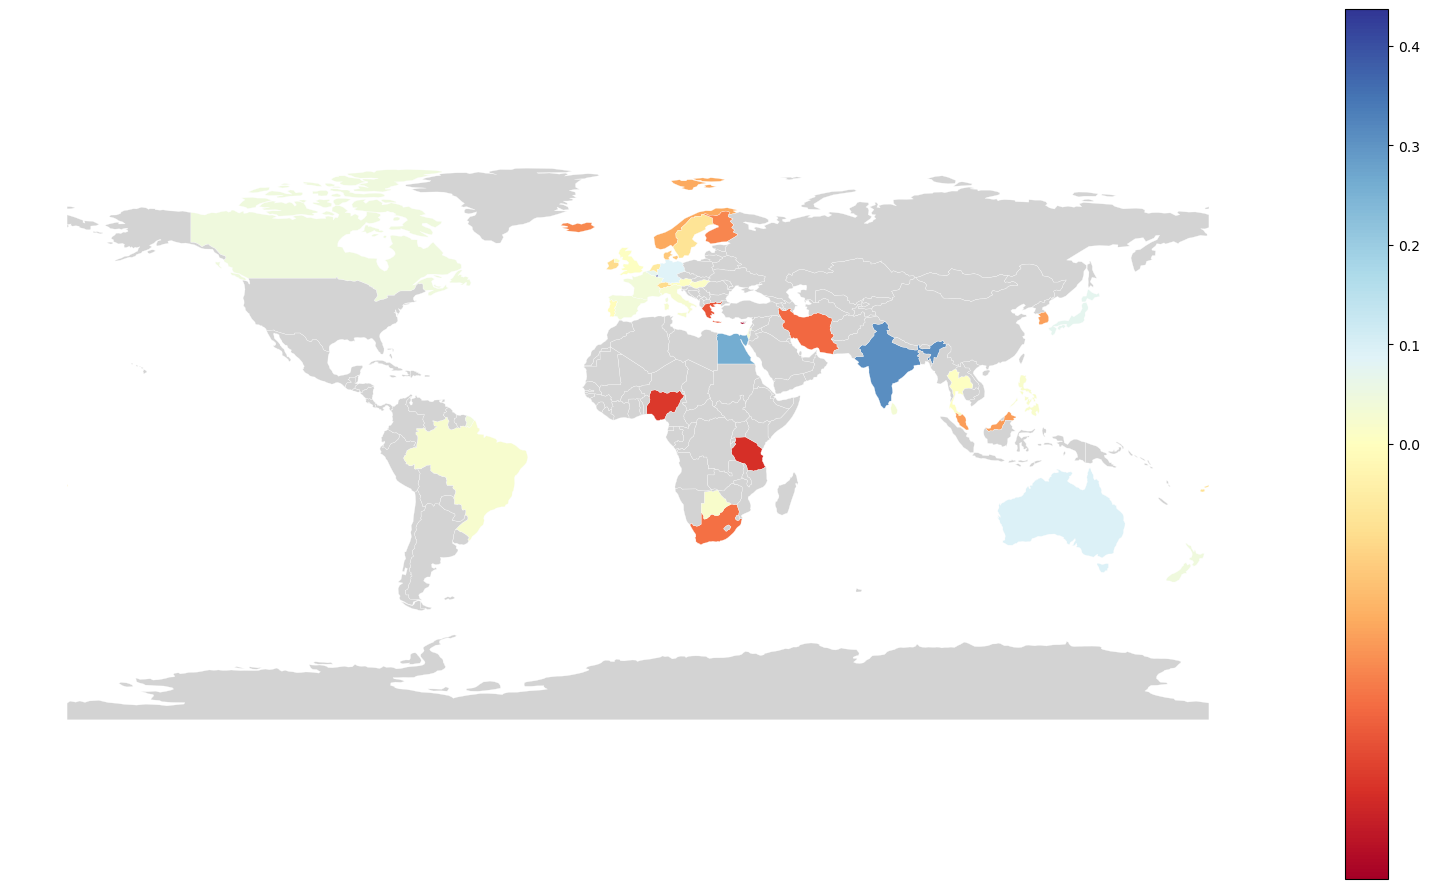

In [73]:
fig, ax = plt.subplots(figsize=(16, 9))

norm = TwoSlopeNorm(
    vmin=merged["value"].min(),
    vcenter=0,
    vmax=merged["value"].max()
)

merged.plot(
    column="value",
    cmap="RdYlBu",
    norm=norm,
    legend=True,
    ax=ax,
    edgecolor="1",
    linewidth=0.2,
    missing_kwds={"color": "lightgrey"}
)

ax.axis("off")

fig.savefig(
    "/Users/lucasdubois/Desktop/LaTeX/MASTER/Images/us_ascm_mundi.png",
    bbox_inches="tight",
    pad_inches=0.02
)
plt.tight_layout()
plt.show()